# Hail M0 - MYRORSS Reanalysis Source Qualification - Meet-the-Data

**Peril:** hail - **Layer:** M0 input evidence - **Mode:** common source qualification with a
CONUS-grid selected-cell adapter proof

This notebook is the first grid-context pass over MYRORSS. It follows the raw-data rule from
`docs/principles/notebook_work/exploratory_data_notebooks.md`: before MYRORSS can enter M1, we need to
understand the source, file layout, sparse grid encoding, units, fill values, and benchmark-cell
aggregation mechanics.

## Step back - why this notebook exists

The current selected-cell M1 pilot is **MRMS-only**. MYRORSS is the next source because it gives us a
longer radar-reanalysis window, but it must not be pasted into the model as an unexplained replacement.

```text
current state:

MRMS daily MESH, Apr-Jun 2024
  -> selected-cell M1 pilot
  -> selected-cell solar M2-M4 smoke test

this notebook:

MYRORSS MESH, one inspected sample day
  -> source and format understanding
  -> sparse grid decode
  -> native pixel -> 0.25 degree benchmark cell aggregation
  -> small sample artifacts with caveats

later, not here:

MYRORSS full record panel, 1998-2011
  -> source harmonization with MRMS
  -> homogeneity / bias checks
  -> frequency and size distribution update
```

Source-role rule:

- MYRORSS is a **long-record gridded evidence extension**.
- It is not a final risk metric source by itself.
- It does not use NOAA reports, NRI, or legacy outputs as substitutes for gridded evidence.
- It must produce the same logical daily-cell evidence contract as MRMS before M1 consumes it.

Plan links:

- `docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md`
- `docs/extra/discussion/conus_grid/hail/00_m1_data_products_research.md`
- `docs/extra/discussion/conus_grid/hail/01_m1_sourcing_triage.md`
- `docs/extra/discussion/conus_grid/hail/02_m1_build_flow.md`
- `docs/principles/notebook_work/exploratory_data_notebooks.md`

## 0 - Scope and non-goals

This notebook does:

1. Verify the MYRORSS S3 layout from the public bucket.
2. Decode one MYRORSS MESH netCDF file and document every variable/attribute we rely on.
3. Reconstruct latitude/longitude from the sparse grid encoding.
4. Aggregate one active sample day to the 0.25 degree benchmark grid.
5. Write small sample artifacts that prove the interface shape.

It deliberately does **not**:

- build a final 1998-2011 MYRORSS climatology;
- replace the MRMS-selected M1 pilot;
- calibrate MYRORSS against MRMS or Storm Events;
- bias-correct MESH;
- fit tails;
- produce EAL, VaR, PML, or TVaR.

The carried-forward object is a source-understanding and aggregation sample, not a production hazard layer.

In [1]:
from __future__ import annotations

import gzip
import json
import math
import tempfile
import xml.etree.ElementTree as ET
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 115})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "common" / "benchmark_grid"
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
RAW_CACHE_DIR = HAIL_GRID_DIR / "raw_myrorss"
RAW_CACHE_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_CELLS_PATH = HAIL_GRID_DIR / "selected_pilot_cells_v2026_06_16.csv"
SERVED_MASK_PATH = GRID_DIR / "served_conus_cell_ids_v2026_06.csv"

SAMPLE_DATE = pd.Timestamp("2010-06-16")
SAMPLE_PREFIX = "2010/06/16/MESH/00.25/"
SAMPLE_KEY = "2010/06/16/MESH/00.25/20100616-201505.netcdf.gz"
SEVERE_HAIL_MM = 25.4
OUTPUT_VERSION = "v2026_06_16"

TOP_CELLS_CSV = HAIL_GRID_DIR / f"myrorss_m0_sample_day_top_cells_20100616_{OUTPUT_VERSION}.csv"
SELECTED_SAMPLE_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cells_sample_day_20100616_{OUTPUT_VERSION}.csv"
SOURCE_PROBE_JSON = HAIL_GRID_DIR / f"myrorss_m0_source_probe_{OUTPUT_VERSION}.json"

print("repo root:", ROOT)
print("MYRORSS raw cache:", RAW_CACHE_DIR)
print("sample day:", SAMPLE_DATE.date(), "(format/aggregation sample only)")
print("severe hail threshold:", SEVERE_HAIL_MM, "mm")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
MYRORSS raw cache: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/raw_myrorss
sample day: 2010-06-16 (format/aggregation sample only)
severe hail threshold: 25.4 mm


## 1 - Source and provenance

Primary source references:

- AWS Open Data Registry: `https://registry.opendata.aws/noaa-oar-myrorss-pds/`
- NOAA repository landing page for the MYRORSS BAMS article: `https://repository.library.noaa.gov/view/noaa/39052`
- NOAA/NSSL overview: `https://inside.nssl.noaa.gov/nsslnews/2020/12/new-data-product-offers-a-more-complete-picture-of-storms/`

Interpretation for this work:

| Item | Meaning | Use decision |
|---|---|---|
| Record | 1998-2011 radar-reanalysis era | Useful for longer historical hail evidence after MRMS contract is proven. |
| Product family | Multi-Year Reanalysis of Remotely Sensed Storms | Treat as reanalysis evidence, not the same operational product as current MRMS. |
| MESH | Maximum Estimated Size of Hail | Candidate gridded hail-size evidence. |
| Grid | Sparse lat/lon grid stored in netCDF | Must reconstruct coordinates before any aggregation. |
| Bucket | `noaa-oar-myrorss-pds` | Public raw source; raw bytes cached under `data/hazard_conus_grid/hail/raw_myrorss/`. |

Important caveat: MYRORSS and MRMS are related through the MRMS framework, but they are not automatically
homogeneous. The later full-record step must check cross-era/source consistency before changing rates.

In [2]:
@dataclass
class MYRORSSClient:
    root_url: str = "https://noaa-oar-myrorss-pds.s3.amazonaws.com"
    cache_dir: Path = RAW_CACHE_DIR
    namespace: str = "{http://s3.amazonaws.com/doc/2006-03-01/}"

    def list_prefixes(self, prefix: str = "") -> list[str]:
        response = requests.get(
            self.root_url + "/",
            params={"list-type": "2", "prefix": prefix, "delimiter": "/", "max-keys": "1000"},
            timeout=60,
        )
        response.raise_for_status()
        root = ET.fromstring(response.content)
        return sorted(
            node.find(self.namespace + "Prefix").text
            for node in root.findall(self.namespace + "CommonPrefixes")
        )

    def list_keys(self, prefix: str) -> list[str]:
        keys: list[str] = []
        token: str | None = None
        while True:
            params = {"list-type": "2", "prefix": prefix, "max-keys": "1000"}
            if token:
                params["continuation-token"] = token
            response = requests.get(self.root_url + "/", params=params, timeout=60)
            response.raise_for_status()
            root = ET.fromstring(response.content)
            keys.extend(
                node.find(self.namespace + "Key").text
                for node in root.findall(self.namespace + "Contents")
            )
            next_token = root.find(self.namespace + "NextContinuationToken")
            if next_token is None:
                break
            token = next_token.text
        return sorted(keys)

    def cache_path(self, key: str) -> Path:
        return self.cache_dir / key.replace("/", "__")

    def fetch(self, key: str) -> Path:
        local = self.cache_path(key)
        if not local.exists():
            response = requests.get(f"{self.root_url}/{quote(key)}", timeout=120)
            response.raise_for_status()
            local.write_bytes(response.content)
        return local

    @staticmethod
    def open_dataset(local_path: Path) -> xr.Dataset:
        raw = local_path.read_bytes()
        if local_path.name.endswith(".gz"):
            raw = gzip.decompress(raw)
        with tempfile.NamedTemporaryFile(suffix=".netcdf") as tmp:
            tmp.write(raw)
            tmp.flush()
            return xr.open_dataset(tmp.name).load()


myrorss = MYRORSSClient()

## 2 - Bucket layout

MYRORSS is delivered as nested year/month/day/product folders. The first thing to check is that the source
structure itself matches the role we expect.

In [3]:
year_prefixes = myrorss.list_prefixes("")
years = [p.strip("/") for p in year_prefixes if p[:4].isdigit()]

sample_day_prefix = SAMPLE_DATE.strftime("%Y/%m/%d/")
products_sample_day = [p.split("/")[-2] for p in myrorss.list_prefixes(sample_day_prefix)]
mesh_keys_sample_day = myrorss.list_keys(SAMPLE_PREFIX)
old_mesh_keys_19990503 = myrorss.list_keys("1999/05/03/MESH/00.25/")

layout_summary = pd.DataFrame(
    [
        ("available_years", f"{min(years)} to {max(years)}", len(years)),
        ("sample_day_products", sample_day_prefix.strip("/"), len(products_sample_day)),
        ("sample_day_mesh_files", SAMPLE_PREFIX, len(mesh_keys_sample_day)),
        ("older_plain_netcdf_example", "1999/05/03/MESH/00.25/", len(old_mesh_keys_19990503)),
    ],
    columns=["check", "scope", "count"],
)
display(layout_summary)

product_col = f"product_folder_{SAMPLE_DATE.strftime('%Y_%m_%d')}"
display(pd.DataFrame({product_col: products_sample_day}).sort_values(product_col).reset_index(drop=True))

extension_examples = pd.DataFrame(
    [
        (f"{SAMPLE_DATE.date()} first key", mesh_keys_sample_day[0]),
        (f"{SAMPLE_DATE.date()} last key", mesh_keys_sample_day[-1]),
        ("1999-05-03 first key", old_mesh_keys_19990503[0] if old_mesh_keys_19990503 else None),
    ],
    columns=["example", "key"],
)
extension_examples["extension"] = extension_examples["key"].str.extract(r"(\.netcdf(?:\.gz)?)$")
display(extension_examples)

,check,scope,count
0,available_years,1998 to 2011,14
1,sample_day_products,2010/06/16,20
2,sample_day_mesh_files,2010/06/16/MESH/00.25/,296
3,older_plain_netcdf_example,1999/05/03/MESH/00.25/,296


,product_folder_2010_06_16
0,EchoTop_18
1,EchoTop_40
2,EchoTop_50
3,H18_Above_0C
4,H40_Above_0C
5,H50_Above_0C
6,MESH
7,MergedLLShear
8,MergedMLShear
9,MergedReflectivityQC


,example,key,extension
0,2010-06-16 first key,2010/06/16/MESH/00.25/20100616-113459.netcdf.gz,.netcdf.gz
1,2010-06-16 last key,2010/06/16/MESH/00.25/20100617-120822.netcdf.gz,.netcdf.gz
2,1999-05-03 first key,1999/05/03/MESH/00.25/19990503-113505.netcdf,.netcdf


**Takeaway.** The source is available as a public daily folder tree from 1998-2011. The MESH product lives
under `MESH/00.25/`, and both plain `.netcdf` and `.netcdf.gz` files exist across the record. The client
therefore has to handle both encodings.

## 3 - Decode one sparse MESH file

The sample file is one timestamp from the active sample day:

```text
2010/06/16/MESH/00.25/20100616-201505.netcdf.gz
```

This is not a final event choice. It is a readable, real file used to understand the data model.

In [4]:
sample_local = myrorss.fetch(SAMPLE_KEY)
sample_ds = myrorss.open_dataset(sample_local)
sample_ds

<xarray.Dataset> Size: 165kB
Dimensions:      (pixel: 13745)
Dimensions without coordinates: pixel
Data variables:
    MESH         (pixel) float32 55kB 1.043 1.441 1.902 ... 1.112 5.006 11.43
    pixel_x      (pixel) int16 27kB 639 641 643 644 814 ... 3195 3196 3196 3196
    pixel_y      (pixel) int16 27kB 2033 2034 2035 2035 ... 4753 4750 4751 4752
    pixel_count  (pixel) int32 55kB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
Attributes: (12/14)
    TypeName:        MESH
    DataType:        SparseLatLonGrid
    Latitude:        55.005
    Longitude:       -130.005
    Height:          250.0
    Time:            1276719305
    ...              ...
    Unit-unit:       dimensionless
    Unit-value:      mm
    LatGridSpacing:  0.01
    LonGridSpacing:  0.01
    MissingData:     -99900.0
    RangeFolded:     -99901.0

In [5]:
attribute_rows = []
for key, value in sample_ds.attrs.items():
    attribute_rows.append((key, value))

attrs_df = pd.DataFrame(attribute_rows, columns=["attribute", "value"])
display(attrs_df)

variable_dictionary = pd.DataFrame(
    [
        (
            "MESH",
            "Maximum Estimated Size of Hail at sparse pixels",
            "mm, from `Unit-value`",
            "YES - hail size estimate; severe threshold is 25.4 mm",
        ),
        (
            "pixel_x",
            "x index in the sparse lat/lon grid",
            "integer pixel index",
            "YES - reconstruct longitude",
        ),
        (
            "pixel_y",
            "y index in the sparse lat/lon grid",
            "integer pixel index",
            "YES - reconstruct latitude",
        ),
        (
            "pixel_count",
            "source sparse-grid count / support field",
            "integer",
            "QA/context only for this first pass",
        ),
        (
            "Latitude",
            "northwest/reference latitude in file attributes",
            "degrees",
            "YES - latitude = Latitude - pixel_y * LatGridSpacing",
        ),
        (
            "Longitude",
            "west/reference longitude in file attributes",
            "degrees",
            "YES - longitude = Longitude + pixel_x * LonGridSpacing",
        ),
        (
            "LatGridSpacing / LonGridSpacing",
            "native grid spacing",
            "degrees",
            "YES - coordinate reconstruction",
        ),
        (
            "MissingData / RangeFolded",
            "sentinel values",
            "not physical hail sizes",
            "MASK if they ever appear in `MESH`",
        ),
    ],
    columns=["field_or_attribute", "what it is", "units / base", "use decision"],
)
display(variable_dictionary)

,attribute,value
0,TypeName,MESH
1,DataType,SparseLatLonGrid
2,Latitude,55.005
3,Longitude,-130.005
4,Height,250.0
5,Time,1276719305
6,FractionalTime,0.0
7,attributes,Unit
8,Unit-unit,dimensionless
9,Unit-value,mm


,field_or_attribute,what it is,units / base,use decision
0,MESH,Maximum Estimated Size of Hail at sparse pixels,"mm, from `Unit-value`",YES - hail size estimate; severe threshold is ...
1,pixel_x,x index in the sparse lat/lon grid,integer pixel index,YES - reconstruct longitude
2,pixel_y,y index in the sparse lat/lon grid,integer pixel index,YES - reconstruct latitude
3,pixel_count,source sparse-grid count / support field,integer,QA/context only for this first pass
4,Latitude,northwest/reference latitude in file attributes,degrees,YES - latitude = Latitude - pixel_y * LatGridS...
5,Longitude,west/reference longitude in file attributes,degrees,YES - longitude = Longitude + pixel_x * LonGri...
6,LatGridSpacing / LonGridSpacing,native grid spacing,degrees,YES - coordinate reconstruction
7,MissingData / RangeFolded,sentinel values,not physical hail sizes,MASK if they ever appear in `MESH`


**Takeaway.** MYRORSS MESH is not a dense `lat x lon` raster in this file. It is a sparse list of pixels,
so the latitude/longitude reconstruction is part of the data interpretation, not a convenience step.

## 4 - Reconstruct coordinates and benchmark `cell_id`

Grid contract cross-reference: `docs/plans/hazard_conus_grid/common/benchmark_grid.md`

The benchmark key is:

```text
cell_id = lat_idx * 1440 + lon_idx
```

For MYRORSS sparse pixels:

```text
lat = Latitude - pixel_y * LatGridSpacing
lon = Longitude + pixel_x * LonGridSpacing
lat_idx = floor((90 - lat) / 0.25)
lon_idx = floor((lon mod 360) / 0.25)
```

In [6]:
def sparse_points(ds: xr.Dataset) -> pd.DataFrame:
    mesh = ds["MESH"].values.astype(float)
    pixel_x = ds["pixel_x"].values.astype(float)
    pixel_y = ds["pixel_y"].values.astype(float)
    pixel_count = ds["pixel_count"].values.astype(int)

    lat = float(ds.attrs["Latitude"]) - pixel_y * float(ds.attrs["LatGridSpacing"])
    lon = float(ds.attrs["Longitude"]) + pixel_x * float(ds.attrs["LonGridSpacing"])
    lat_idx = np.floor((90.0 - lat) / 0.25).astype(int)
    lon_idx = np.floor(np.mod(lon, 360.0) / 0.25).astype(int)
    cell_id = lat_idx * 1440 + lon_idx

    out = pd.DataFrame(
        {
            "mesh_mm": mesh,
            "pixel_x": pixel_x.astype(int),
            "pixel_y": pixel_y.astype(int),
            "pixel_count": pixel_count,
            "lat": lat,
            "lon": lon,
            "lat_idx": lat_idx,
            "lon_idx": lon_idx,
            "cell_id": cell_id,
        }
    )
    out["timestamp_utc"] = pd.to_datetime(int(ds.attrs["Time"]), unit="s", utc=True)
    return out


def summarize_sparse_file(ds: xr.Dataset) -> pd.Series:
    points = sparse_points(ds)
    return pd.Series(
        {
            "typename": ds.attrs.get("TypeName"),
            "data_type": ds.attrs.get("DataType"),
            "timestamp_utc": points["timestamp_utc"].iloc[0],
            "n_sparse_pixels": len(points),
            "mesh_min_mm": float(points["mesh_mm"].min()),
            "mesh_p95_mm": float(points["mesh_mm"].quantile(0.95)),
            "mesh_max_mm": float(points["mesh_mm"].max()),
            "n_severe_sparse_pixels": int((points["mesh_mm"] >= SEVERE_HAIL_MM).sum()),
            "lat_min": float(points["lat"].min()),
            "lat_max": float(points["lat"].max()),
            "lon_min": float(points["lon"].min()),
            "lon_max": float(points["lon"].max()),
        }
    )


sample_points = sparse_points(sample_ds)
sample_summary = summarize_sparse_file(sample_ds).to_frame("value")
display(sample_summary)

display(sample_points.sort_values("mesh_mm", ascending=False).head(10))

,value
typename,MESH
data_type,SparseLatLonGrid
timestamp_utc,2010-06-16 20:15:05+00:00
n_sparse_pixels,13745
mesh_min_mm,0.803427
mesh_p95_mm,11.74431
mesh_max_mm,50.406487
n_severe_sparse_pixels,46
lat_min,-3.405
lat_max,46.035


,mesh_mm,pixel_x,pixel_y,pixel_count,lat,lon,lat_idx,lon_idx,cell_id,timestamp_utc
334,50.406487,953,2042,1,34.585,-120.475,221,958,319198,2010-06-16 20:15:05+00:00
346,47.813240,954,2042,1,34.585,-120.465,221,958,319198,2010-06-16 20:15:05+00:00
321,45.757683,952,2042,1,34.585,-120.485,221,958,319198,2010-06-16 20:15:05+00:00
333,44.821442,953,2041,1,34.595,-120.475,221,958,319198,2010-06-16 20:15:05+00:00
320,44.537498,952,2041,1,34.595,-120.485,221,958,319198,2010-06-16 20:15:05+00:00
358,38.248013,955,2043,1,34.575,-120.455,221,958,319198,2010-06-16 20:15:05+00:00
345,37.578827,954,2041,1,34.595,-120.465,221,958,319198,2010-06-16 20:15:05+00:00
13002,37.267159,2637,4871,1,6.295,-103.635,334,1025,481985,2010-06-16 20:15:05+00:00
304,36.934872,951,2041,1,34.595,-120.495,221,958,319198,2010-06-16 20:15:05+00:00
319,36.910690,952,2040,1,34.605,-120.485,221,958,319198,2010-06-16 20:15:05+00:00


**Takeaway.** The decoded file has physical MESH values in millimeters and enough coordinate metadata to
place sparse pixels onto the benchmark grid. The sample timestamp contains severe-hail pixels, so it is
useful for visual inspection.

## 5 - Visualize the decoded sample file

This plot is intentionally simple: raw sparse MYRORSS MESH pixels, colored by estimated hail size, with the
four selected pilot-cell centers overlaid. It is a source-understanding plot, not a final hazard map.

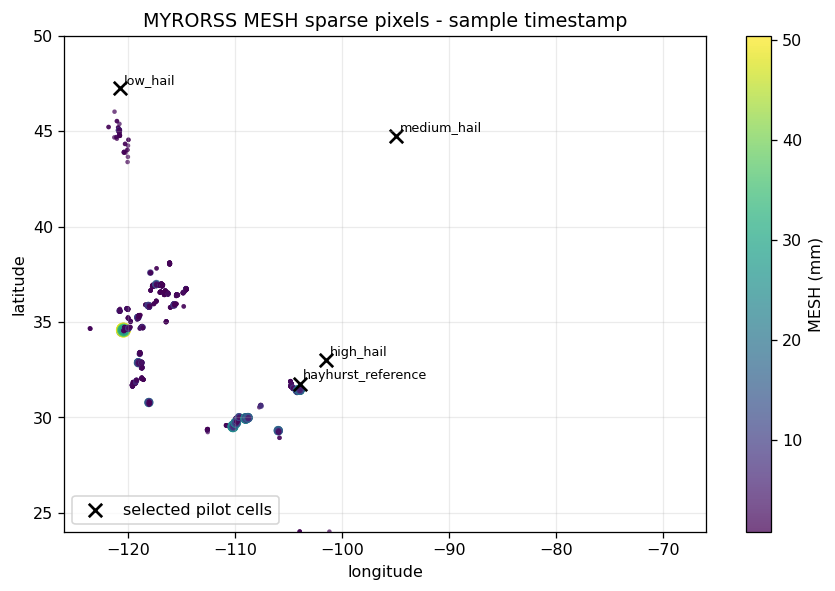

In [7]:
selected_cells = pd.read_csv(SELECTED_CELLS_PATH)
served = pd.read_csv(SERVED_MASK_PATH)
served_cell_ids = set(served["cell_id"].astype(int))

fig, ax = plt.subplots(figsize=(9, 5.6))
plot_points = sample_points.query("-126 <= lon <= -66 and 24 <= lat <= 50").copy()
sc = ax.scatter(
    plot_points["lon"],
    plot_points["lat"],
    c=plot_points["mesh_mm"],
    s=np.clip(plot_points["mesh_mm"] * 1.8, 8, 90),
    cmap="viridis",
    alpha=0.72,
    linewidths=0,
)
ax.scatter(
    selected_cells["lon_center"],
    selected_cells["lat_center"],
    marker="x",
    s=70,
    c="black",
    linewidths=1.7,
    label="selected pilot cells",
)
for _, row in selected_cells.iterrows():
    ax.text(row["lon_center"] + 0.35, row["lat_center"] + 0.25, row["role"], fontsize=8)

ax.set_title("MYRORSS MESH sparse pixels - sample timestamp")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_xlim(-126, -66)
ax.set_ylim(24, 50)
ax.legend(loc="lower left")
cb = fig.colorbar(sc, ax=ax, label="MESH (mm)")
plt.show()

**Takeaway.** The reconstructed points land in plausible CONUS storm regions, and the selected-cell
markers can be compared directly. This specific timestamp is active, but not active over the four selected
cells.

## 6 - Aggregate one sample day to benchmark cells

We aggregate all MYRORSS MESH files for `2010-06-16` to the 0.25 degree served CONUS cells.

Important base/denominator:

- `positive_native_pixel_records` counts sparse positive pixel records across all source timestamps.
- `severe_native_pixel_records` counts sparse pixel records with MESH >= 25.4 mm across all timestamps.
- `n_timestamps_with_positive_mesh` is not a daily frequency. It is within-day source support.
- `hail_day_flag` is the one-day daily-cell severe-hail flag for this sample day only.

This is the shape the full MYRORSS panel will later use, but this one-day output is not a climatology.

In [8]:
def aggregate_day_to_cells(keys: list[str], served_ids: set[int]) -> pd.DataFrame:
    stats: dict[int, dict[str, object]] = defaultdict(
        lambda: {
            "positive_native_pixel_records": 0,
            "severe_native_pixel_records": 0,
            "n_timestamps_with_positive_mesh": 0,
            "n_timestamps_with_severe_mesh": 0,
            "mesh_max_mm": np.nan,
            "mesh_p95_seen_values_mm": np.nan,
            "first_timestamp_utc": None,
            "last_timestamp_utc": None,
        }
    )

    served_id_array = np.array(sorted(served_ids), dtype=np.int64)

    for idx, key in enumerate(keys, start=1):
        ds = myrorss.open_dataset(myrorss.fetch(key))
        points = sparse_points(ds)
        points = points[np.isin(points["cell_id"].values, served_id_array)]
        if points.empty:
            continue

        timestamp = points["timestamp_utc"].iloc[0]
        points["is_severe"] = points["mesh_mm"] >= SEVERE_HAIL_MM
        grouped = points.groupby("cell_id").agg(
            positive_native_pixel_records=("mesh_mm", "size"),
            severe_native_pixel_records=("is_severe", "sum"),
            mesh_max_mm=("mesh_mm", "max"),
            mesh_p95_seen_values_mm=("mesh_mm", lambda s: float(s.quantile(0.95))),
        )

        for cell_id, row in grouped.iterrows():
            cell = stats[int(cell_id)]
            cell["positive_native_pixel_records"] += int(row["positive_native_pixel_records"])
            cell["severe_native_pixel_records"] += int(row["severe_native_pixel_records"])
            cell["n_timestamps_with_positive_mesh"] += 1
            if int(row["severe_native_pixel_records"]) > 0:
                cell["n_timestamps_with_severe_mesh"] += 1

            prior_max = cell["mesh_max_mm"]
            cell["mesh_max_mm"] = (
                float(row["mesh_max_mm"])
                if pd.isna(prior_max)
                else max(float(prior_max), float(row["mesh_max_mm"]))
            )
            prior_p95 = cell["mesh_p95_seen_values_mm"]
            cell["mesh_p95_seen_values_mm"] = (
                float(row["mesh_p95_seen_values_mm"])
                if pd.isna(prior_p95)
                else max(float(prior_p95), float(row["mesh_p95_seen_values_mm"]))
            )
            cell["first_timestamp_utc"] = (
                timestamp if cell["first_timestamp_utc"] is None else min(cell["first_timestamp_utc"], timestamp)
            )
            cell["last_timestamp_utc"] = (
                timestamp if cell["last_timestamp_utc"] is None else max(cell["last_timestamp_utc"], timestamp)
            )

        if idx % 75 == 0:
            print(f"processed {idx:,} / {len(keys):,} MYRORSS files")

    out = pd.DataFrame.from_dict(stats, orient="index").reset_index(names="cell_id")
    out["date"] = SAMPLE_DATE.date().isoformat()
    out["source"] = "MYRORSS"
    out["source_product"] = "MESH/00.25"
    out["n_source_files"] = len(keys)
    out["severe_threshold_mm"] = SEVERE_HAIL_MM
    out["hail_day_flag"] = out["mesh_max_mm"] >= SEVERE_HAIL_MM
    out = out.merge(
        served[["cell_id", "lat_center", "lon_center", "state_abbr", "iso_rto"]],
        on="cell_id",
        how="left",
    )
    ordered = [
        "source",
        "source_product",
        "date",
        "cell_id",
        "lat_center",
        "lon_center",
        "state_abbr",
        "iso_rto",
        "hail_day_flag",
        "mesh_max_mm",
        "mesh_p95_seen_values_mm",
        "positive_native_pixel_records",
        "severe_native_pixel_records",
        "n_timestamps_with_positive_mesh",
        "n_timestamps_with_severe_mesh",
        "n_source_files",
        "first_timestamp_utc",
        "last_timestamp_utc",
        "severe_threshold_mm",
    ]
    return out[ordered].sort_values(["hail_day_flag", "severe_native_pixel_records", "mesh_max_mm"], ascending=False)


daily_cell_summary = aggregate_day_to_cells(mesh_keys_sample_day, served_cell_ids)
print("served cells with any positive MYRORSS sparse pixel on sample day:", len(daily_cell_summary))
print("served cells with severe MYRORSS sparse pixel on sample day:", int(daily_cell_summary["hail_day_flag"].sum()))

top_cells = daily_cell_summary.head(50).copy()
display(top_cells.head(20))

processed 75 / 296 MYRORSS files


processed 150 / 296 MYRORSS files


processed 225 / 296 MYRORSS files


served cells with any positive MYRORSS sparse pixel on sample day: 620
served cells with severe MYRORSS sparse pixel on sample day: 18


,source,source_product,date,cell_id,lat_center,lon_center,state_abbr,iso_rto,hail_day_flag,mesh_max_mm,mesh_p95_seen_values_mm,positive_native_pixel_records,severe_native_pixel_records,n_timestamps_with_positive_mesh,n_timestamps_with_severe_mesh,n_source_files,first_timestamp_utc,last_timestamp_utc,severe_threshold_mm
500,MYRORSS,MESH/00.25,2010-06-16,288981,40.00,-114.75,NV,WEIM,True,44.862740,36.418163,384,162,1,1,296,2010-06-16 23:00:05+00:00,2010-06-16 23:00:05+00:00,25.4
498,MYRORSS,MESH/00.25,2010-06-16,287541,40.25,-114.75,NV,WEIM,True,39.198952,34.530894,393,106,1,1,296,2010-06-16 23:00:05+00:00,2010-06-16 23:00:05+00:00,25.4
496,MYRORSS,MESH/00.25,2010-06-16,286101,40.50,-114.75,NV,WEIM,True,35.000324,31.333640,357,67,1,1,296,2010-06-16 23:00:05+00:00,2010-06-16 23:00:05+00:00,25.4
298,MYRORSS,MESH/00.25,2010-06-16,337984,31.50,-104.00,TX,ERCOT,True,37.829437,33.161934,1649,63,22,6,296,2010-06-16 19:45:05+00:00,2010-06-16 21:40:05+00:00,25.4
494,MYRORSS,MESH/00.25,2010-06-16,284661,40.75,-114.75,NV,WEIM,True,38.767021,31.842136,361,54,1,1,296,2010-06-16 23:00:05+00:00,2010-06-16 23:00:05+00:00,25.4
231,MYRORSS,MESH/00.25,2010-06-16,319198,34.75,-120.50,CA,CAISO,True,50.406487,36.999267,1869,48,28,7,296,2010-06-16 19:05:05+00:00,2010-06-16 21:20:05+00:00,25.4
259,MYRORSS,MESH/00.25,2010-06-16,320640,34.50,-120.00,CA,CAISO,True,40.259426,26.231970,1625,34,21,4,296,2010-06-16 19:20:05+00:00,2010-06-16 22:00:05+00:00,25.4
339,MYRORSS,MESH/00.25,2010-06-16,336540,31.75,-105.00,TX,ERCOT,True,37.738430,24.113774,1848,17,21,3,296,2010-06-16 20:10:05+00:00,2010-06-16 22:00:05+00:00,25.4
492,MYRORSS,MESH/00.25,2010-06-16,283221,41.00,-114.75,NV,WEIM,True,31.683222,25.798636,289,16,1,1,296,2010-06-16 23:00:05+00:00,2010-06-16 23:00:05+00:00,25.4
499,MYRORSS,MESH/00.25,2010-06-16,288980,40.00,-115.00,NV,WEIM,True,39.362652,35.534286,21,13,1,1,296,2010-06-16 23:00:05+00:00,2010-06-16 23:00:05+00:00,25.4


**Takeaway.** The daily aggregation produces the same kind of cell-level evidence object we need for M1:
source, date, cell, severity threshold, max size, within-day support counts, and provenance. It is still a
one-day sample.

## 7 - Selected-cell sample-day readout

The current four selected pilot cells were chosen from Apr-Jun 2024 MRMS, not from the 2010 MYRORSS sample
day. We still join them here to test the selected-cell interface and to show whether the sample day
intersects them.

In [9]:
selected_sample = selected_cells[
    ["hazard", "selection_version", "role", "cell_id", "lat_center", "lon_center", "state_abbr", "iso_rto"]
].merge(
    daily_cell_summary.drop(columns=["lat_center", "lon_center", "state_abbr", "iso_rto"]),
    on="cell_id",
    how="left",
)

fill_zero_cols = [
    "positive_native_pixel_records",
    "severe_native_pixel_records",
    "n_timestamps_with_positive_mesh",
    "n_timestamps_with_severe_mesh",
]
for col in fill_zero_cols:
    selected_sample[col] = selected_sample[col].fillna(0).astype(int)
selected_sample["n_source_files"] = selected_sample["n_source_files"].fillna(len(mesh_keys_sample_day)).astype(int)
selected_sample["source"] = selected_sample["source"].fillna("MYRORSS")
selected_sample["source_product"] = selected_sample["source_product"].fillna("MESH/00.25")
selected_sample["date"] = selected_sample["date"].fillna(SAMPLE_DATE.date().isoformat())
selected_sample["severe_threshold_mm"] = selected_sample["severe_threshold_mm"].fillna(SEVERE_HAIL_MM)
selected_sample["hail_day_flag"] = selected_sample["hail_day_flag"].fillna(False).astype(bool)
selected_sample["coverage_status"] = np.where(
    selected_sample["positive_native_pixel_records"] > 0,
    "source_files_available_sparse_mesh_seen",
    "source_files_available_no_sparse_mesh_pixel",
)

selected_sample["sample_day_use"] = np.where(
    selected_sample["hail_day_flag"],
    "format_and_positive_selected_cell_example",
    "format_only_no_selected_cell_severe_hit",
)
selected_sample["qa_note"] = (
    "One MYRORSS day used to test source decoding and selected-cell join. "
    "A zero here means no sparse MYRORSS severe MESH record in this sample day, not low climatology."
)

display(
    selected_sample[
        [
            "role",
            "cell_id",
            "date",
            "hail_day_flag",
            "mesh_max_mm",
            "positive_native_pixel_records",
            "severe_native_pixel_records",
            "n_source_files",
            "coverage_status",
            "sample_day_use",
        ]
    ]
)

,role,cell_id,date,hail_day_flag,mesh_max_mm,positive_native_pixel_records,severe_native_pixel_records,n_source_files,coverage_status,sample_day_use
0,high_hail,329354,2010-06-16,False,NaN,0,0,296,source_files_available_no_sparse_mesh_pixel,format_only_no_selected_cell_severe_hit
1,medium_hail,261700,2010-06-16,False,NaN,0,0,296,source_files_available_no_sparse_mesh_pixel,format_only_no_selected_cell_severe_hit
2,low_hail,247197,2010-06-16,False,NaN,0,0,296,source_files_available_no_sparse_mesh_pixel,format_only_no_selected_cell_severe_hit
3,hayhurst_reference,336544,2010-06-16,False,16.107588,84,0,296,source_files_available_sparse_mesh_seen,format_only_no_selected_cell_severe_hit


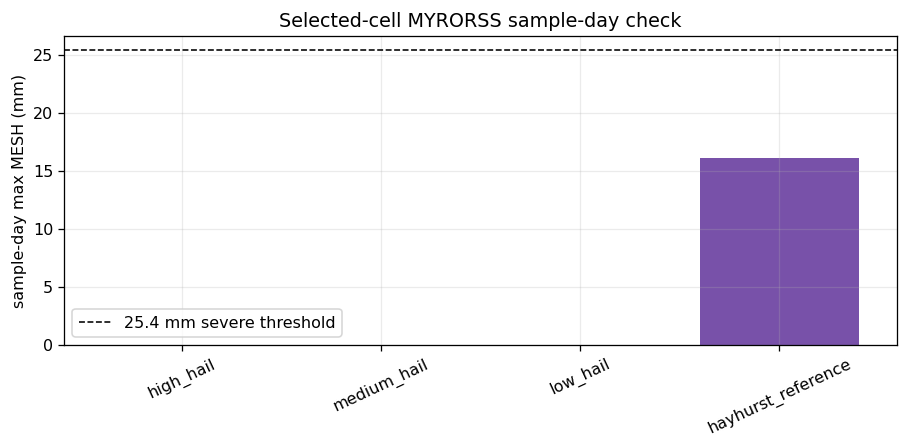

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = selected_sample.assign(mesh_max_mm=selected_sample["mesh_max_mm"].fillna(0.0))
ax.bar(plot_df["role"], plot_df["mesh_max_mm"], color=["#b23a48", "#4f7cac", "#7f8c4a", "#7851a9"])
ax.axhline(SEVERE_HAIL_MM, color="black", linestyle="--", linewidth=1, label="25.4 mm severe threshold")
ax.set_ylabel("sample-day max MESH (mm)")
ax.set_title("Selected-cell MYRORSS sample-day check")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway.** This sample day is useful for source mechanics and CONUS-cell aggregation, but it does not
provide positive selected-cell severe evidence. The full MYRORSS step must scan the record for these cells
rather than extrapolating from this one sample.

## 8 - Sample-day severe-cell visualization

The top daily cells below are not candidate selections. They are a visual QA that the daily aggregation is
producing plausible grid-cell geography and severity ordering.

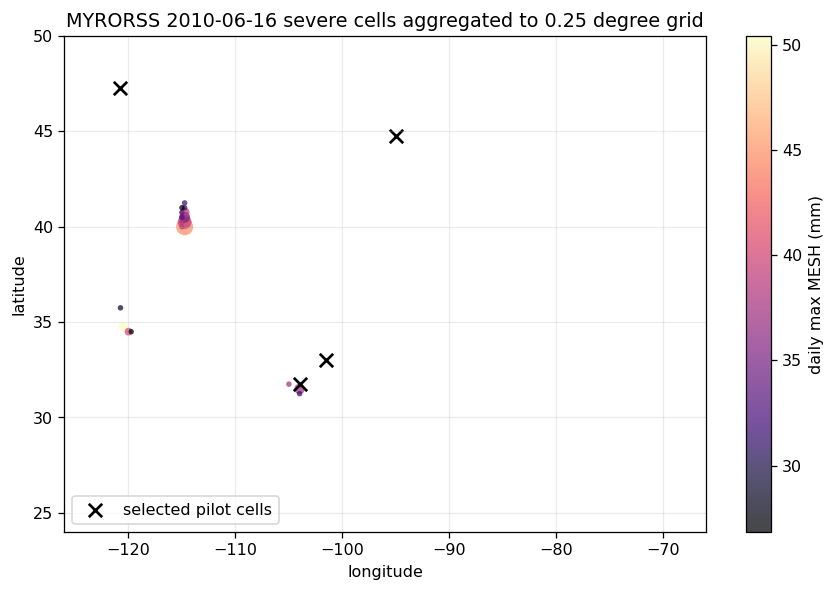

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.6))
severe_cells = daily_cell_summary[daily_cell_summary["hail_day_flag"]].copy()
sc = ax.scatter(
    severe_cells["lon_center"],
    severe_cells["lat_center"],
    c=severe_cells["mesh_max_mm"],
    s=np.clip(severe_cells["severe_native_pixel_records"] * 0.7, 12, 180),
    cmap="magma",
    alpha=0.72,
    linewidths=0,
)
ax.scatter(
    selected_cells["lon_center"],
    selected_cells["lat_center"],
    marker="x",
    s=70,
    c="black",
    linewidths=1.7,
    label="selected pilot cells",
)
ax.set_xlim(-126, -66)
ax.set_ylim(24, 50)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("MYRORSS 2010-06-16 severe cells aggregated to 0.25 degree grid")
ax.legend(loc="lower left")
fig.colorbar(sc, ax=ax, label="daily max MESH (mm)")
plt.show()

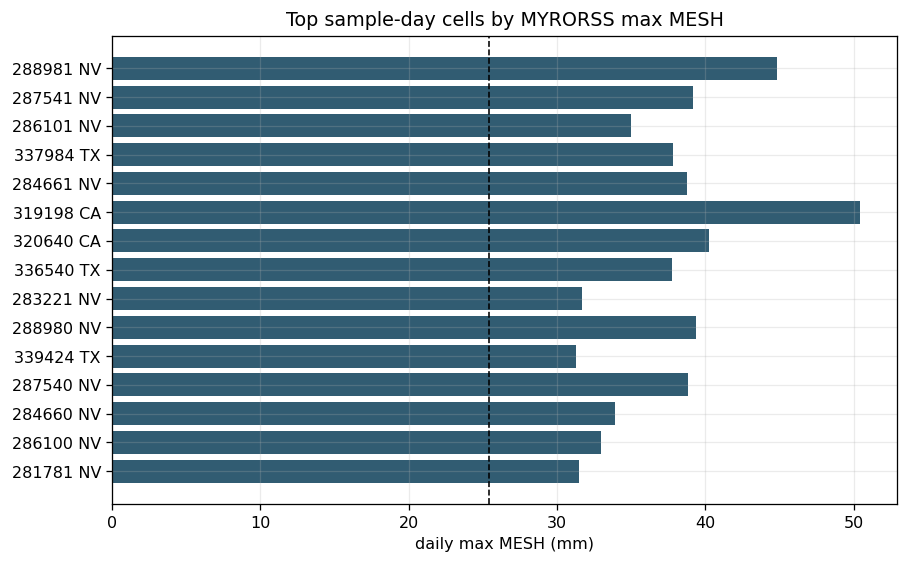

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
bar_df = top_cells.head(15).copy()
labels = bar_df["cell_id"].astype(str) + " " + bar_df["state_abbr"].fillna("")
ax.barh(labels[::-1], bar_df["mesh_max_mm"][::-1], color="#315c72")
ax.axvline(SEVERE_HAIL_MM, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("daily max MESH (mm)")
ax.set_title("Top sample-day cells by MYRORSS max MESH")
plt.tight_layout()
plt.show()

**Takeaway.** The severe-cell map is coherent for a central/eastern severe-weather day and shows that the
aggregation creates a usable cell-level ranking. This is the mechanics we will reuse for a longer record,
not a final cell-selection basis.

## 9 - Write carried-forward sample artifacts

These outputs are intentionally small and labeled as M0 samples:

- top sample-day cells: proves daily CONUS-cell aggregation;
- selected-cell sample-day table: proves selected-cell join and zero handling;
- source probe JSON: records source layout, sample key, caveats, and next decisions.

In [13]:
top_cells.to_csv(TOP_CELLS_CSV, index=False)
selected_sample.to_csv(SELECTED_SAMPLE_CSV, index=False)

source_probe = {
    "version": OUTPUT_VERSION,
    "hazard": "hail",
    "source": "MYRORSS",
    "source_role": "long-record gridded evidence extension after MRMS contract is proven",
    "root_url": myrorss.root_url,
    "sample_date": SAMPLE_DATE.date().isoformat(),
    "sample_prefix": SAMPLE_PREFIX,
    "sample_key": SAMPLE_KEY,
    "record_years_seen": [min(years), max(years)],
    "sample_day_mesh_file_count": len(mesh_keys_sample_day),
    "older_plain_netcdf_example_key": old_mesh_keys_19990503[0] if old_mesh_keys_19990503 else None,
    "severe_threshold_mm": SEVERE_HAIL_MM,
    "sample_outputs": {
        "top_cells_csv": str(TOP_CELLS_CSV.relative_to(ROOT)),
        "selected_cells_csv": str(SELECTED_SAMPLE_CSV.relative_to(ROOT)),
    },
    "allowed_use": [
        "source format/provenance understanding",
        "native sparse pixel to benchmark cell aggregation proof",
        "input for designing the full MYRORSS selected-cell scan",
    ],
    "not_allowed_use": [
        "final MYRORSS climatology",
        "MRMS replacement",
        "reportable EAL/PML/VaR/TVaR input",
        "hail frequency estimate",
    ],
    "caveats": [
        "one active sample day only",
        "selected pilot cells have no severe hit on this sample day",
        "MYRORSS and operational MRMS require cross-era/source homogeneity checks",
        "MESH bias and tail treatment are unresolved",
    ],
    "primary_source_links": [
        "https://registry.opendata.aws/noaa-oar-myrorss-pds/",
        "https://repository.library.noaa.gov/view/noaa/39052",
        "https://inside.nssl.noaa.gov/nsslnews/2020/12/new-data-product-offers-a-more-complete-picture-of-storms/",
    ],
}
SOURCE_PROBE_JSON.write_text(json.dumps(source_probe, indent=2) + "\n")

print("wrote:", TOP_CELLS_CSV.relative_to(ROOT))
print("wrote:", SELECTED_SAMPLE_CSV.relative_to(ROOT))
print("wrote:", SOURCE_PROBE_JSON.relative_to(ROOT))

wrote: data/hazard_conus_grid/hail/myrorss_m0_sample_day_top_cells_20100616_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cells_sample_day_20100616_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_source_probe_v2026_06_16.json


## 10 - Decision notes for the next step

What we learned:

1. MYRORSS MESH is accessible from the public `noaa-oar-myrorss-pds` bucket.
2. The source uses a year/month/day/product layout, and the MESH product is under `MESH/00.25/`.
3. Files can be `.netcdf` or `.netcdf.gz`; the reader must handle both.
4. The MESH files are sparse lat/lon grids, so coordinate reconstruction is required.
5. The benchmark `cell_id` formula works once coordinates are reconstructed.
6. One-day aggregation can produce the same logical daily-cell evidence shape as MRMS.

What remains before MYRORSS can enter M1:

1. Scan the full 1998-2011 record for the four selected cells.
2. Materialize explicit zero days and coverage/no-data flags.
3. Compare MYRORSS selected-cell rates/sizes against MRMS where overlap or comparable windows exist.
4. Decide whether MYRORSS becomes a separate source-era panel, an extension, or a calibration input.
5. Document MESH bias and tail treatment before using high-return risk metrics.

Immediate next notebook candidate:

```text
Notebooks/hail/m0_input_data/03_myrorss_reanalysis_source_qualification/
  02_selected_cell_record_scan.py
```

That notebook should run selected-cell first, not full CONUS, so we can inspect source consistency before
widening the record.